# Handwritten Digit Recognition
This notebook implements a simple Neural Network to recognize handwritten digits from the MNIST dataset using **NumPy**, **Pandas**, and **Matplotlib**.

Data is loaded from the `Archive/` directory containing PNG images.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## 1. Load the Dataset from PNG Images
We will iterate through the `Archive/training` and `Archive/testing` folders to load the images.

In [2]:
def load_mnist_png(base_path):
    X = []
    Y = []
    print(f"Scanning {base_path}...")
    for label in range(10):
        folder_path = os.path.join(base_path, str(label))
        if not os.path.exists(folder_path):
            print(f"  Warning: Folder for label {label} not found in {base_path}")
            continue
            
        files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
        print(f"  Loading {len(files)} images for digit {label}...")
        
        for filename in files:
            img_path = os.path.join(folder_path, filename)
            # plt.imread returns values in [0, 1] for PNGs
            img = plt.imread(img_path)
            X.append(img.flatten())
            Y.append(label)
            
    return np.array(X), np.array(Y)

train_path = 'Archive/training'
test_path = 'Archive/testing'

if os.path.exists(train_path):
    X_train_raw, Y_train_raw = load_mnist_png(train_path)
    X_test_raw, Y_test_raw = load_mnist_png(test_path)
    
    print(f"\nTotal Training samples: {X_train_raw.shape[0]}")
    print(f"Total Testing samples: {X_test_raw.shape[0]}")
else:
    print("ERROR: 'Archive/training' folder not found. Please ensure the data is in the correct location.")

Scanning Archive/training...
  Loading 5923 images for digit 0...
  Loading 6742 images for digit 1...
  Loading 5958 images for digit 2...
  Loading 6131 images for digit 3...
  Loading 5842 images for digit 4...
  Loading 5421 images for digit 5...
  Loading 5918 images for digit 6...
  Loading 6265 images for digit 7...
  Loading 5851 images for digit 8...
  Loading 5949 images for digit 9...
Scanning Archive/testing...
  Loading 980 images for digit 0...
  Loading 1135 images for digit 1...
  Loading 1032 images for digit 2...
  Loading 1010 images for digit 3...
  Loading 982 images for digit 4...
  Loading 892 images for digit 5...
  Loading 958 images for digit 6...
  Loading 1028 images for digit 7...
  Loading 974 images for digit 8...
  Loading 1009 images for digit 9...

Total Training samples: 60000
Total Testing samples: 10000


## 2. Preprocessing
We shuffle the training data and prepare the arrays for the Neural Network. 
Note: Since `plt.imread` already provides values in range `[0, 1]`, further normalization is optional but we ensure consistency.

In [3]:
# Combine training data for easier shuffling
train_data = np.c_[Y_train_raw, X_train_raw]
np.random.shuffle(train_data)

m, n = train_data.shape

# Dev set (validation) - first 1000 samples
data_dev = train_data[0:1000].T
Y_dev = data_dev[0].astype(int)
X_dev = data_dev[1:n]

# Training set - remaining samples
data_train = train_data[1000:m].T
Y_train = data_train[0].astype(int)
X_train = data_train[1:n]
_, m_train = X_train.shape

# Test set
X_test = X_test_raw.T
Y_test = Y_test_raw

## 3. Neural Network Implementation
Simple 2-layer network:
- Input: 784 (28x28)
- Hidden: 10 (ReLU)
- Output: 10 (Softmax)

In [4]:
def init_params():
    # Random weights between -0.5 and 0.5
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0)) # Numeric stability
    return exp_Z / np.sum(exp_Z, axis=0)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m_batch = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m_batch * dZ2.dot(A1.T)
    db2 = 1 / m_batch * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m_batch * dZ1.dot(X.T)
    db1 = 1 / m_batch * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

## 4. Training Loop

In [5]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    accuracy_history = []
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        
        predictions = get_predictions(A2)
        accuracy = get_accuracy(predictions, Y)
        accuracy_history.append(accuracy)
        
        if i % 100 == 0:
            print("Iteration: ", i)
            print("Accuracy: ", accuracy)
    return W1, b1, W2, b2, accuracy_history

Iteration:  0
Accuracy:  0.18313559322033898
Iteration:  100
Accuracy:  0.7533220338983051
Iteration:  200
Accuracy:  0.8266101694915254
Iteration:  300
Accuracy:  0.8543898305084746
Iteration:  400
Accuracy:  0.869406779661017


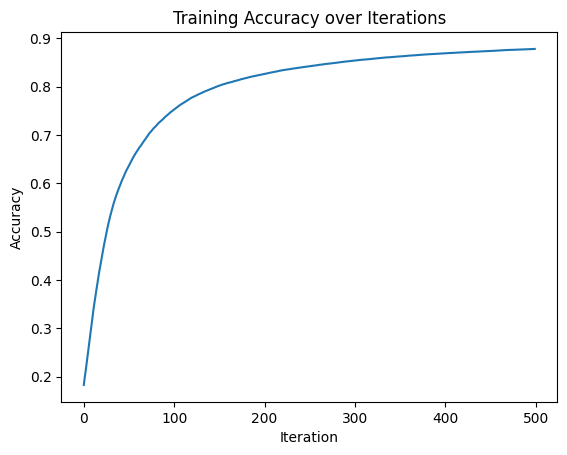

In [6]:
W1, b1, W2, b2, accuracy_history = gradient_descent(X_train, Y_train, 0.15, 500)

plt.plot(accuracy_history)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Iterations")
plt.show()

## 5. Model Evaluation

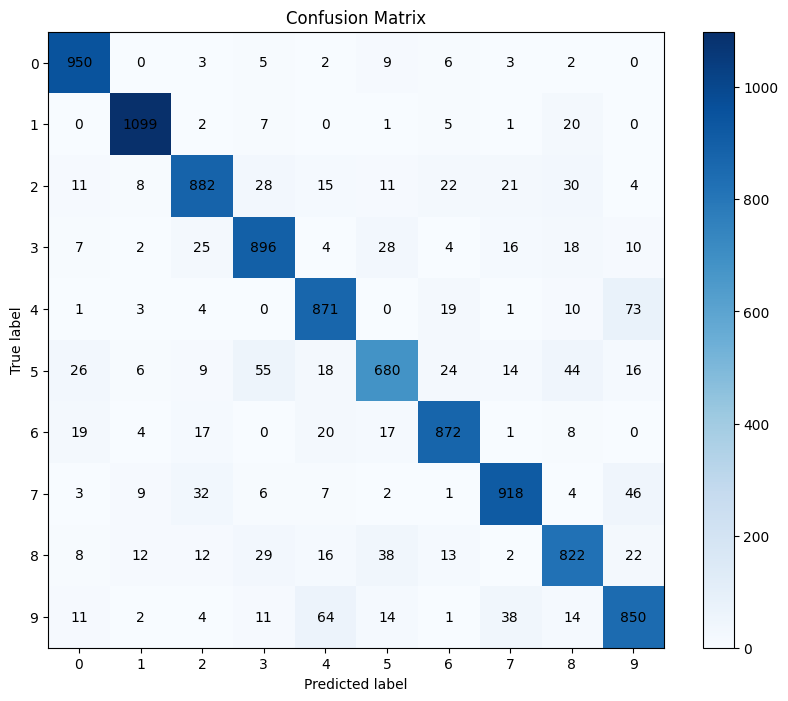

In [7]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

test_predictions = make_predictions(X_test, W1, b1, W2, b2)

def confusion_matrix(actual, predicted):
    classes = np.unique(actual)
    matrix = np.zeros((len(classes), len(classes)))
    for a, p in zip(actual, predicted):
        matrix[a][p] += 1
    return matrix

cm = confusion_matrix(Y_test, test_predictions)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()